# Décodage précoce ("early decoding") et interprétabilité de modèles de langues

On va reproduire une expérience d'interprétabilité qui consiste à projeter les sorties des couches intermédiaires d'un transformer vers le vocabulaire du modèle, pour étudier l'évolution des prédictions depuis la couche 0 jusqu'à la dernière.

<p style="text-align:center;">
<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TALNGG/TP_2025/TP3_2025_26/images/solveit.png" alt="Texte alternatif" style="width:30%; height:auto;" title="Titre optionnel" />
</p>

Cette méthode popularisée par l'outil LogitLens est parfois appelée *early decoding*, cf :

 [Language Models Implement Simple Word2Vec-style Vector Arithmetic](https://aclanthology.org/2024.naacl-long.281/) (Merullo et al., NAACL 2024)

__`Résumé (Abstract)`__

Une critique majeure envers les modèles de langage (LM) concerne leur opacité ("inscrutabilité"). Cet article démontre que, malgré leur taille et complexité, les LMs utilisent parfois un mécanisme simple d'arithmétique vectorielle pour résoudre des tâches relationnelles (ex: Pologne:Varsovie :: Chine:Pékin). 

En étudiant des modèles allant de 124M à 176B de paramètres dans un cadre d'apprentissage en contexte (in-context learning), les auteurs découvrent que pour des tâches comme les capitales, les majuscules ou le temps passé, le mécanisme clé se réduit à une simple mise à jour additive appliquée par les réseaux à propagation avant (FFN). 

Ce mécanisme est spécifique aux tâches nécessitant une récupération depuis la mémoire de pré-entraînement, plutôt que depuis le contexte local.
​

__`1. Introduction`.__ 

L'article explore comment les LLMs rappellent l'information. Contrairement à la complexité de l'architecture Transformer, les chercheurs trouvent que les LLMs implémentent un mécanisme d'addition vectorielle qualitativement similaire à celui des anciens plongements de mots statiques (type Word2Vec).

_`Trois résultats clés sont présentés`_

 - __Signature de traitement__ : 
   - Une séquence distincte "Argument-Fonction" est observée. 
   - Le modèle prépare d'abord le sujet (l'argument, ex: "Pologne") dans les couches intermédiaires, puis applique une fonction (ex: "get_capital") pour produire la réponse ("Varsovie").
​
 - __Rôle des FFN__ : 
   - Ce mécanisme est souvent implémenté par les couches FFN (Feed-Forward Networks) des couches moyennes à tardives. 
   - Ces FFN produisent des vecteurs de mise à jour indépendants du contexte.

 - __Mémoire vs Contexte__ : 
   - Ce mécanisme est spécifique au rappel d'informations apprises (tâches "abstractives"). 
   - Si la réponse est déjà dans le prompt (tâches "extractives"), ce mécanisme ne joue aucun rôle et les FFN peuvent même être retirés sans grande perte de performance.      
​

__`2. Méthodologie`__

Les auteurs utilisent la technique de `"Early Decoding"` (décodage précoce) pour observer l'évolution de la prédiction du prochain token à travers les couches du modèle (voir "logit lens"). Ils analysent trois tâches principales :

 - Capitales du monde (France -> Paris).
 - Mise en majuscules (brown -> Brown).
 - Conjugaison au passé (abandon -> abandoned).

__`3. Résultats et Découvertes`__ 

 - __Les étapes du traitement__ : Le modèle passe par trois phases :    
 - __Formation de l'argument__ : Le token sujet monte dans le classement des probabilités.        
 - __Application de la fonction__ : Un changement brusque se produit, souvent via une couche FFN, transformant le sujet en réponse.   
 - __Saturation__ : La réponse est trouvée et reste stable jusqu'à la couche finale.    
 - __Interventions sur les vecteurs__ : 
    - Les chercheurs ont réussi à isoler les vecteurs de sortie des FFN responsables de ces transformations. 
    - Ils peuvent "injecter" ces vecteurs dans d'autres contextes pour forcer le modèle à exécuter la fonction (ex: transformer "Chine" en "Pékin" dans un contexte absurde).    
 - __Ablation des FFN__ : En retirant certaines couches FFN, la performance s'effondre pour les tâches nécessitant une connaissance externe (abstractives), mais reste stable pour les tâches de copie (extractives), suggérant que les FFN stockent les faits et les têtes d'attention gèrent la copie locale.    

On va ici utiliser la librairie d'interprétabilité NNsight pour avoir accès aux valeurs internes du modèle de langue.

cf https://nnsight.net/notebooks/tutorials/get_started/walkthrough/

Une partie de ce qui suit est inspirée du tutoriel sur logit lens: https://nnsight.net/notebooks/tutorials/probing/logit_lens/.

In [12]:
try:
    import google.colab #type: ignore
    is_colab = True
except ImportError:
    is_colab = False

#%pip -q install -U nnsight

In [13]:
# Import
import torch
import numpy as np
import pandas as pds
from IPython.display import clear_output
from nnsight import LanguageModel # type: ignore
from typing import List, Callable

In [14]:
# On prend un modèle "pas trop gros" publique, "emballé" par nnsight pour être facilement utilisable ensuite
model = LanguageModel("openai-community/gpt2", device_map="auto", dispatch=True)
# vous pouvez aussi essayer de voir la différence avec un modèle de meme ordre grandeur mais plus de couches
# model = LanguageModel("EleutherAI/gpt-neo-1.3B", device_map="auto", dispatch=True)

L'architecture du modèle nous donne les couches pertinentes qui seront accessibles: ici ce sont les 12 blocks GPT (transformer.h)

In [15]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
  (generator): Generator(
    (streamer): Streamer()
  )
)


__`Observons la structure du modèle ! GPT-2 possède`__ :     
 - __transformer.wte__ représentations vectorielles de jetons
 - __transformer.h__ une liste des blocs transformateurs (couches 0 à 11)
 - __lm_head__ la projection de la sortie vers le vocabulaire

__`NNsight donne plusieurs outils d'analyse`__:      
 - un objet __tracer__ qui permet de précalculer ce qu'on va regarder dans le modèle. 
 - Le modèle sera éxécuté seulement à la fin du block __with__.
 - A l'intérieur, on peut préparer plusieurs calculs sur différents prompts dans le block __with...invoke__
 - Les prompts seront ensuite batchés avant d'être envoyés réellement au modèle 
 - Chacun des contextes __invoke__ va donner accès aux entrées/sorties des couches du modèle
 - Pour avoir accès à ces calculs ensuite, il faut appeler la méthode __.save()__

`Le paradigme de base : l’entrelacement`. 
Lorsque l'on écrit du code d'intervention à l'intérieur d'un bloc, voici ce qui se passe réellement :   
`with model.trace(...)`
- Le code est capturé (nnsight extrait le code à l’intérieur du withbloc).
- Le code est compilé en une fonction exécutable
- Le code s'exécute en parallèle avec le modèle : pendant la feed forward le code d'intervention s'exécute simultanément.
- Le code attend des valeurs, lorsque l'on accéde à une valeur .output, il se met en pause jusqu'à ce que le modèle atteigne ce point.
- Le modèle fournit des valeurs via des hooks ; 
- les hooks PyTorch injectent des valeurs dans le code en attente.
- Le code peut modifier les valeurs ; avant que le feed forward ne se poursuive, on peut modifier les activations.

`Ce processus est appelé entrelacement` : 
- le code d’intervention et la passe avant du modèle s’exécutent tour à tour, synchronisés à des points spécifiques (entrées et sorties du module).

<p style="text-align:center;">
<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TALNGG/TP_2025/TP3_2025_26/images/entrelacement.png" alt="entrelacement" style="width:50%; height:auto;" title="Titre optionnel" />
</p>

In [16]:
ids1 = model.tokenizer("The Eiffel Tower which is in the city of")["input_ids"]
ids2 = model.tokenizer("We love the Eiffel Tower which is in the city of")["input_ids"]

print(len(ids1), len(ids2))
print(model.tokenizer.convert_ids_to_tokens(ids1))
print(model.tokenizer.convert_ids_to_tokens(ids2))

11 13
['The', 'ĠE', 'iff', 'el', 'ĠTower', 'Ġwhich', 'Ġis', 'Ġin', 'Ġthe', 'Ġcity', 'Ġof']
['We', 'Ġlove', 'Ġthe', 'ĠE', 'iff', 'el', 'ĠTower', 'Ġwhich', 'Ġis', 'Ġin', 'Ġthe', 'Ġcity', 'Ġof']


In [17]:
# cf doc nnsight, exemple logitlens (factorisé)
# Observons la structure du modèle ! GPT-2 possède :
#. - transformer.wte: représentations vectorielles de jetons
#. - transformer.h: une liste des blocs transformateurs (couches 0 à 11)
#. - lm_head: la projection de la sortie vers le vocabulaire

def decode_at_all_layers(model,prompt= "La tour effeil est dans quelle ville"):
      layers = model.transformer.h
      probs_layers = []
      # Python utilise le withmot-clé `context` pour entrer dans un objet de type contexte.
      # L'outil principal de NNsight est un contexte de traçage, on y accède en appelant model.trace(<input>)
      with model.trace() as tracer:
          # one invoke per prompt (1 seul ici)
          with tracer.invoke(prompt) as invoker:
            # store input tokens
            input_tokens = invoker.inputs.save()
            for layer_idx, layer in enumerate(layers):
                # Process layer output through the model's head and layer normalization
                # layer.output[0] est le résidu de sortie du bloc layer_idx (forme [batch, seq_len, d_model]).
                # le premier élément (output[0]) est précisément le tenseur hidden_states (forme [batch, seq_len, d_model]).
                layer_output = model.lm_head(model.transformer.ln_f(layer.output[0]))
                # Apply softmax to obtain probabilities and save the result
                # Les valeurs accédées dans la trace qui n'existent que pendant la durée de celle-ci. 
                # Elles ne sont conservées après la fin du contexte que si nous .save()les appelons.
                probs = torch.nn.functional.softmax(layer_output, dim=-1).save() # type: ignore
                probs_layers.append(probs)

      probs = torch.cat([probs for probs in probs_layers])
      # Find the maximum probability and corresponding tokens for each position
      max_probs, tokens = probs.max(dim=-1)

      # Decode token IDs to words for each layer at each position in the sequence
      words = [[model.tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in layer_tokens]
          for layer_tokens in tokens]

      # Access the 'input_ids' attribute of the invoker object to get the input words
      input_words = [model.tokenizer.decode(t) for t in input_tokens[1]['input_ids'][0]]

      #
      return words,input_words,max_probs,probs,tokens

In [183]:
all_words,input_words,max_probs,probs,tokens = decode_at_all_layers(model,"The Eiffel Tower is in the city of")

In [19]:
# exemple: chaque token prédit après le dernier token de la séquence, pour chaque couche (de 0 à 11)
print([x[-1] for x in all_words])

[' the', ' the', ' the', ' the', ' the', ' the', ' East', ' Ing', ' Rome', ' London', ' Paris', ' Paris']


Avec une belle visualisation fournie par la doc nnsight (factorisée):



In [20]:
%pip -q install plotly
%pip -q install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


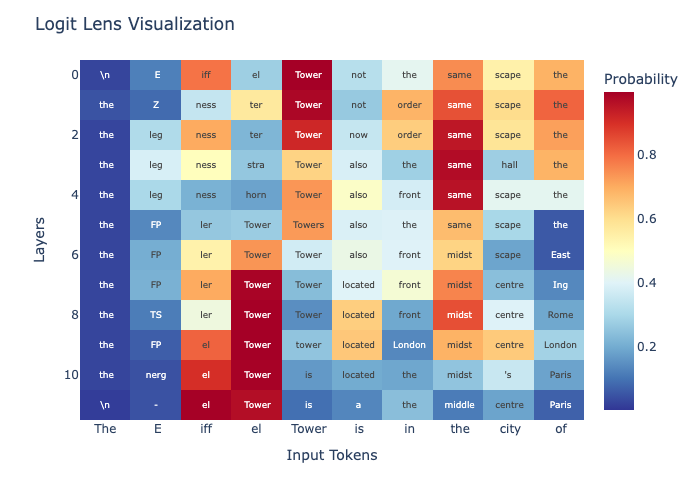

In [184]:
import plotly.express as px #type: ignore
import plotly.io as pio #type: ignore
pio.renderers.default = "colab" if is_colab else "notebook_connected+plotly_mimetype+png"
# pio.renderers.default = "colab" if is_colab else "png"


def display_probs(words,input_words,max_probs):
    fig = px.imshow(
        max_probs.detach().cpu().numpy(),
        x=input_words,
        y=list(range(len(words))),
        color_continuous_scale=px.colors.diverging.RdYlBu_r,
        color_continuous_midpoint=0.50,
        text_auto=True,
        labels=dict(x="Input Tokens", y="Layers", color="Probability")
    )

    fig.update_layout(
        title='Logit Lens Visualization',
        xaxis_tickangle=0
    )

    fig.update_traces(text=words, texttemplate="%{text}")
    fig.show()

display_probs(all_words, input_words, max_probs)

**A faire: quelques questions sur le modèle**

- quels sont les identifiants des noms des villes Paris, London, Rome qui apparaissent dans la visualisation ? Cela aidera dans la suite.
Pour être sur d'avoir la bonne chaine, allez voir dans une des variables résultats de l'execution précédente quand le mot apparait comme prédiction (on voit sur la figure que ce sont les prédictions des dernières couches pour le dernier token de la séquence)

- extrayer la distribution de probabilités du 8e token, dernière couche. A quelle position sont placées les 3 noms de ville ?


In [22]:
# quelques fcts pour se simplifier un peu la vie
def token2id(word,model):
  """renvoie l'identifiant d'une chaine de caractère si elle est bien dans le vocabulaire"""
  return model.tokenizer.convert_tokens_to_ids(word)

def id2token(id,model):
  """renvoie la chaine correspondant à l'identifiant dans le vocabulaire du modele"""
  return model.tokenizer.convert_ids_to_tokens(id)

In [239]:
paris_id  = token2id("Paris", model)
london_id = token2id("London", model)
rome_id   = token2id("Rome", model)

print(f'input_words :  {input_words}')
print(f'tokens :       {tokens.shape}')
print(f'probs :        {probs.shape}')
print(f'probs[11][8] : {probs[11][8].shape}\n')

vec_probs = probs[11].detach().cpu().numpy()
pos = vec_probs.shape[0] -1
proba_paris = vec_probs[pos][paris_id]
proba_london = vec_probs[pos][london_id]
sorted_indices = np.argsort(-vec_probs[pos])
rank_paris = int(np.where(sorted_indices == paris_id)[0][0])
rank_london = int(np.where(sorted_indices == london_id)[0][0])
rank_rome = int(np.where(sorted_indices == rome_id)[0][0])

print(f'distribution de probabilités du 8e token, dernière couche  :\n {vec_probs[8]}')
print(f'pos : {pos}, rank_paris: {rank_paris}, rank_london: {rank_london}, rank_rome: {rank_rome}')
print(f'probs[paris_id]: {vec_probs[pos][paris_id]:.8f}, probs[london_id]: {vec_probs[pos][london_id]:.8f}, probs[rome_id]: {vec_probs[pos][rome_id]:.8f}')



input_words :  ['The', ' E', 'iff', 'el', ' Tower', ' is', ' in', ' the', ' city', ' of']
tokens :       torch.Size([12, 10])
probs :        torch.Size([12, 10, 50257])
probs[11][8] : torch.Size([50257])

distribution de probabilités du 8e token, dernière couche  :
 [5.7721807e-04 1.3571922e-04 2.7107742e-08 ... 8.3704021e-09 1.9652389e-07
 1.2447213e-05]
pos : 9, rank_paris: 8770, rank_london: 6347, rank_rome: 8563
probs[paris_id]: 0.00000104, probs[london_id]: 0.00000240, probs[rome_id]: 0.00000111


**A faire : questions principales**


## 1 Localisation des décisions:
on repart du modèle où on a juste gardé toutes les prédictions pour toutes les couches
- regarder les distributions de probabilité des deux termes London/Paris dans les 12 couches finales pour voir leurs évolutions respectives, pareil pour le classement des deux tokens. Faites une fonction qui fait une figure, par exemple en mettant les résultats dans une table pandas.


Ceci devrait ressembler aux résultats du papier de Merullo et al., figure de gauche (attention ce n'est pas le même exemple dans leur papier, et leur modèle a 24 couches): faire une figure qui montre l'évolution de la probabilité de "Paris" et "London" depuis la couche 0 jusqu'à la couche 12.
Pareil pour le rang des 2 termes (ou bien la mesure de l'article de Merullo, le Mean reciprocal rank qui est juste 1/rang).


In [240]:
def data_evolution(model, prompt="The Eiffel Tower is in the city of"):
    records = []
    paris_id = token2id("Paris", model)
    london_id = token2id("London", model)
    all_words,input_words,max_probs,probs,tokens = decode_at_all_layers(model,prompt)
    for layer_idx, (prob_layer, tokens_layer,max_prob_layer) in enumerate(zip(probs,tokens,max_probs)):  
        pos = prob_layer.shape[0] - 1  
        proba_paris = prob_layer.detach().cpu().numpy()[pos][paris_id]
        proba_london = prob_layer.detach().cpu().numpy()[pos][london_id]
        sorted_indices = np.argsort(-prob_layer[pos].detach().cpu().numpy())
        rank_paris = int(np.where(sorted_indices == paris_id)[0][0])
        rank_london = int(np.where(sorted_indices == london_id)[0][0])
        record = {
            "layer": layer_idx,
            "p_Paris": proba_paris,
            "rank_Paris": rank_paris,
            "p_London": proba_london,
            "rank_Paris": rank_london,
            } 
        records.append(record)
    df = pds.DataFrame(records)
    return df
data_evolution(model)

,layer,p_Paris,rank_Paris,p_London
0,0,4.593088e-09,17925,1.300676e-07
1,1,5.101334e-10,19386,2.595158e-08
2,2,7.124251e-10,10649,1.094424e-07
3,3,2.326041e-09,10877,8.952058e-08
4,4,1.340589e-08,11365,5.607806e-08
5,5,8.017249e-08,5334,6.055180e-07
6,6,3.352962e-08,4180,5.572044e-07
7,7,2.986716e-08,3673,4.553358e-07
8,8,3.101898e-08,3230,4.358822e-07
9,9,6.000790e-07,1157,1.915863e-06


In [241]:
import matplotlib.pyplot as plt

def plot_paris_london_2x2(df_list, titles=None):
    fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True) # type : ignore

    if titles is None:
        titles = [f"Prompt {i+1}" for i in range(4)]

    for i, ax in enumerate(axes.ravel()):
        df = df_list[i]

        # points + lignes
        ax.scatter(df["layer"], df["p_Paris"], s=15, color="tab:blue", label="P(Paris)")
        ax.scatter(df["layer"], df["p_London"], s=15, color="tab:orange", label="P(London)")
        ax.plot(df["layer"], df["p_Paris"], color="tab:blue", linewidth=1, alpha=0.7)
        ax.plot(df["layer"], df["p_London"], color="tab:orange", linewidth=1, alpha=0.7)

        ax.set_title(titles[i], fontsize=9)
        ax.tick_params(axis="both", labelsize=8)

        # légende seulement sur un subplot (par ex. en haut à droite)
        if i == 1:
            ax.legend(fontsize=8)

    fig.text(0.5, 0.04, "Layer", ha="center", fontsize=10)
    fig.text(0.04, 0.5, "Probability", va="center", rotation="vertical", fontsize=10)

    plt.tight_layout(rect=[0.06, 0.06, 1, 1]) # type: ignore
    plt.show()

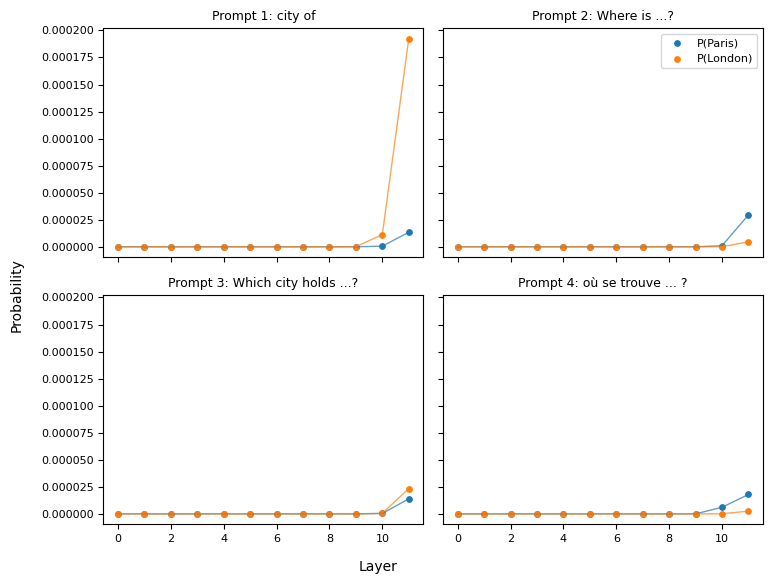

In [242]:
df_prompt1 = "In which city is Buckingham Palace located?"
df_prompt2 = "In which city is le 'Sacré Coeur' located?"
df_prompt3 = "In which city is the 'Eiffel Tower' located?"
df_prompt4 = "What is the capital of France?"

prompts = [df_prompt1, df_prompt2, df_prompt3, df_prompt4]

# 1) on calcule un df par prompt

df_list = [data_evolution(model, p) for p in prompts]
#df_list = [paris_london_evolution(model, p) for p in prompts]

# 2) titres optionnels
titles = [
    "Prompt 1: city of",
    "Prompt 2: Where is ...?",
    "Prompt 3: Which city holds ...?",
    "Prompt 4: où se trouve ... ?",
    "Prompt 5: où se trouve ... ?"
]

# 3) affichage 2x2
plot_paris_london_2x2(df_list, titles=titles)


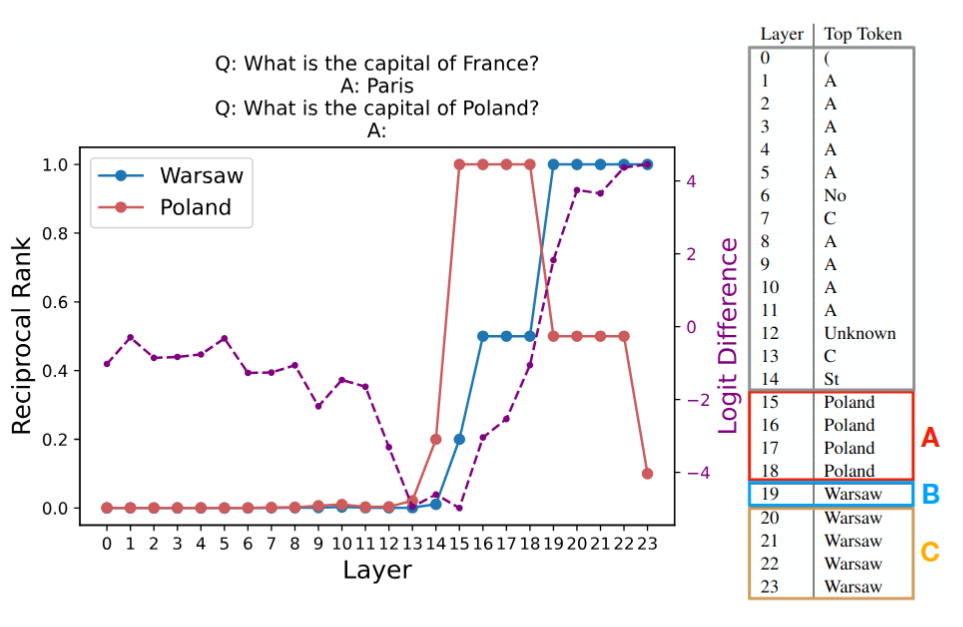


**A faire: questions principales**

## 2. Influence des couches

 - On peut aussi forcer le calcul à sauter des couches avec l'opération skip (cf exemple ci-dessous) 
 - Cela permet de remplacer la sortie d'une couche par des valeurs données (ex: résultat d'une couche précédente)

- Réaliser une fonction qui permet:  
   - l'éxécution comme au début, 
   - mais en sautant une couche de numéro donné. 
   - Pour faire simple, on ne saute pas la couche 0

- trouvez quelle(s) suppressions de couches changent le résultat de la prédiction finale (sauf la dernière)
- pour une de ces couches, retracez les changements de proba de London et Paris, comme à la question 1

In [ ]:
# exemple de saut de couche:
print(prompt)
with model.trace() as tracer:

    with tracer.invoke(prompt):
        # skip la couche 1 en remplaçant la sortie par la sortie de la couche 0
        model.transformer.h[1].skip(model.transformer.h[0].output)